In [2]:
using Flux, Zygote, Distributions, Bijectors, Plots, StatsPlots, LinearAlgebra

In [3]:
struct MSGARCH11 #use Gaussian distribution
    initial_state_probs
    transition_probs
    
    alphas
    betas
    omegas
    initial_sigmas
    
    mus
end
Flux.@functor MSGARCH11

function MSGARCH11(n_states::Int) 
    initial_state_probs = randn(n_states) .* 0.1
    transition_probs = randn(n_states, n_states) .* 0.1
    
    alphas = randn(n_states).*0.1
    betas = randn(n_states).*0.1
    omegas = randn(n_states).*0.1
    initial_sigmas = randn(n_states) .* 0.1
    
    mus = zeros(n_states)
    
    return MSGARCH11(initial_state_probs, transition_probs, alphas, betas, omegas, initial_sigmas, mus)
end

function model_filter(m::MSGARCH11, y, y_tm1, sigmas_tm1, state_probs_tm1) 
    transition_probs = softmax(m.transition_probs, dims=2)
    
    alphas = σ.(m.alphas)
    betas = σ.(m.betas) .* (1. .- alphas) #ensure that alpha + beta < 1 --> GARCH stationarity
    omegas = exp.(m.omegas)
    
    mus = m.mus
    
    state_probs_t = transition_probs * state_probs_tm1
    sigmas_t = sqrt.(omegas .+ alphas .* y_tm1.^2 .+ betas .* sigmas_tm1.^2)
    
    y_t = y[1]
    dists_t = Normal.(mus,sigmas_t)
    pdfs_t = pdf.(dists_t, y_t)
    
    filtered_probs_t = state_probs_t .* pdfs_t ./ sum(state_probs_t .* pdfs_t)
    
    if length(y) > 1
        state_probs_tp1, filtered_probs_tp1, dists_tp1, pdfs_tp1 = model_filter(m, y[2:end], y_t, sigmas_t, filtered_probs_t)
        return hcat(state_probs_t, state_probs_tp1), 
               hcat(filtered_probs_t, filtered_probs_tp1),
               hcat(dists_t, dists_tp1),
               hcat(pdfs_t, pdfs_tp1)
    else
        return state_probs_t, filtered_probs_t, dists_t, pdfs_t
    end
end


function filter(m::MSGARCH11, y)
    n_states = length(m.initial_state_probs)
    
    y_t = 0.0
    sigmas_t = exp.(m.initial_sigmas)
    state_probs_t = softmax(m.initial_state_probs)
    
    return model_filter(m, y, y_t, sigmas_t, state_probs_t)
end

filter (generic function with 1 method)

In [4]:
using MarketData

In [5]:
start = DateTime(2017, 1, 1)

df = yahoo(:AAPL, YahooOpt(period1 = start))
prices = df["AdjClose"]


1693×1 TimeArray{Float64, 1, Date, Vector{Float64}} 2017-01-03 to 2023-09-25
│            │ AdjClose │
├────────────┼──────────┤
│ 2017-01-03 │ 27.0593  │
│ 2017-01-04 │ 27.029   │
│ 2017-01-05 │ 27.1665  │
│ 2017-01-06 │ 27.4693  │
│ 2017-01-09 │ 27.7209  │
│ 2017-01-10 │ 27.7489  │
│ 2017-01-11 │ 27.898   │
│ 2017-01-12 │ 27.7815  │
│ 2017-01-13 │ 27.7326  │
│ 2017-01-17 │ 27.9562  │
│ 2017-01-18 │ 27.9539  │
│ ⋮          │ ⋮        │
│ 2023-09-12 │ 176.3    │
│ 2023-09-13 │ 174.21   │
│ 2023-09-14 │ 175.74   │
│ 2023-09-15 │ 175.01   │
│ 2023-09-18 │ 177.97   │
│ 2023-09-19 │ 179.07   │
│ 2023-09-20 │ 175.49   │
│ 2023-09-21 │ 173.93   │
│ 2023-09-22 │ 174.79   │
│ 2023-09-25 │ 176.08   │

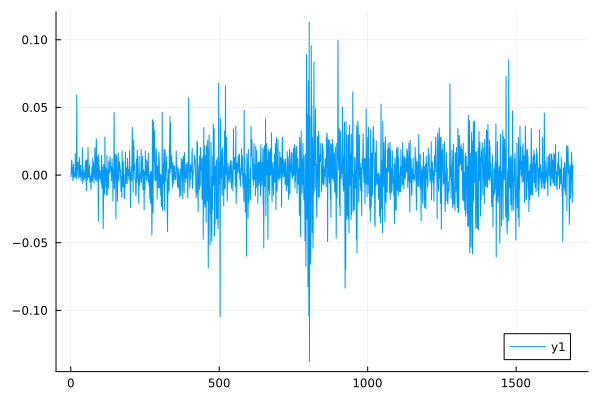

In [6]:
rets = diff(log.(values(prices)))
plot(rets)

MSGARCH11([0.028025501822015377, 0.03391794957024074], [-0.10640238571660665 0.05781917033681999; 0.06476058166269304 0.11945913134915448], [0.021231355883637792, 0.1347167111870023], [0.03491877313655601, -0.09754865584294703], [0.2192873976737719, -0.12735539642163288], [0.1084864129647971, -0.0759690601667061], [0.0, 0.0])

In [8]:
model = MSGARCH11(2)
params = Flux.params(model)
opt = ADAM(0.01)

Adam(0.01, (0.9, 0.999), 1.0e-8, IdDict{Any, Any}())

In [110]:
function loglikelihood(m::MSGARCH11, y)
     _,f_probs,_,pdfs = filter(m, y)
    return mean(log.(sum(f_probs.*pdfs,dims=1)))
end

loglikelihood (generic function with 1 method)

In [10]:
Zygote.gradient(()->loglikelihood(model, rets./std(rets)),params)

Grads(...)

In [60]:
for i in 1:500
    grads = Zygote.gradient(()-> -loglikelihood(model, rets),params)
    Flux.Optimise.update!(opt,params,grads)
    
    if i % 25 == 0
        println(loglikelihood(model, rets))
    end
end 

1.8299050706112385
1.9244175563658223
2.0123831044694076
2.0937857868321914
2.167437398976546
2.2333505684840205
2.2918293669687806
2.3427570822455057
2.3862902833170287
2.423416408163846
2.456219854360962
2.484826278222939
2.510848033405608
2.5338496020704353
2.551166681672357
2.5724354717766422
2.5903474408770397
2.60645911178085
2.6215011365241074
2.63235028285531


In [61]:
_,f_probs,dists,pdfs = filter(model, rets./std(rets))

([0.04790691402025278 0.7263754097416444 … 0.7856440597586459 0.5533024245907927; 0.8325290142117184 0.3334936008144678 … 0.28989960131522363 0.4607943513096222], [0.7413258634463936 0.9999999997913035 … 0.5568226630835911 0.7981621759127425; 0.2586741365536063 2.086965479802466e-10 … 0.44317733691640904 0.20183782408725745], Normal{Float64}[Normal{Float64}(μ=-0.0032747498839299943, σ=0.7300259235937865) Normal{Float64}(μ=-0.0032747498839299943, σ=0.7409913464213448) … Normal{Float64}(μ=-0.0032747498839299943, σ=0.8800297248661418) Normal{Float64}(μ=-0.0032747498839299943, σ=0.7850468056481568); Normal{Float64}(μ=0.0018425898390247335, σ=0.015238789182210484) Normal{Float64}(μ=0.0018425898390247335, σ=0.037387401882919745) … Normal{Float64}(μ=0.0018425898390247335, σ=0.28888822436231054) Normal{Float64}(μ=0.0018425898390247335, σ=0.15757419813808016)], [0.5449284557266203 0.5045079165017089 … 0.43398748354171 0.4503678582607836; 0.010941633441700157 2.2932789224655808e-10 … 0.936086663

In [62]:
pdfs

2×1692 Matrix{Float64}:
 0.544928   0.504508     0.389629    …  0.320183  0.433987  0.450368
 0.0109416  2.29328e-10  0.00270722     0.486333  0.936087  0.136752

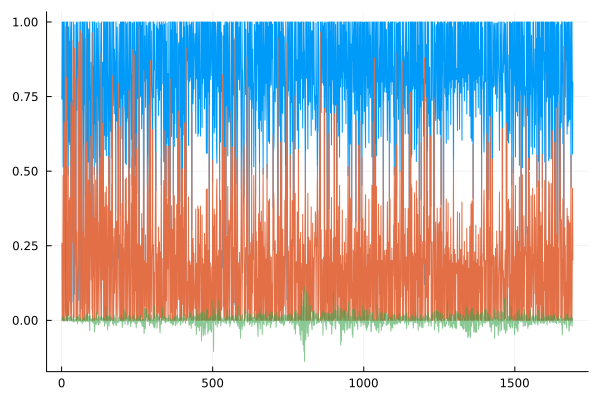

In [63]:
plot(transpose(f_probs),legend = :none)
plot!(rets,alpha=0.6)

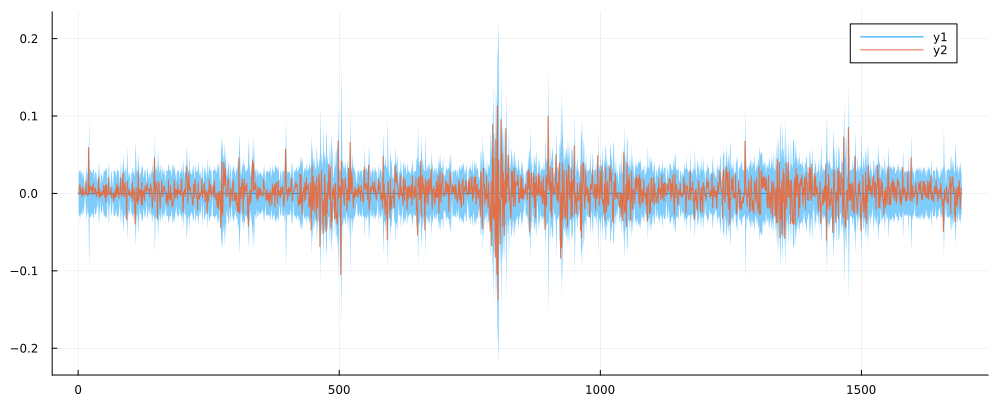

In [64]:
mixprobs = []
for i in 1:length(rets)
    push!(mixprobs,MixtureModel(Flux.unstack(dists,2)[i], Flux.unstack(f_probs,2)[i]))
end
plot(zeros(length(rets)), ribbon = 2 .* std.(mixprobs).*std(rets), size = (1000,400))
plot!(rets)

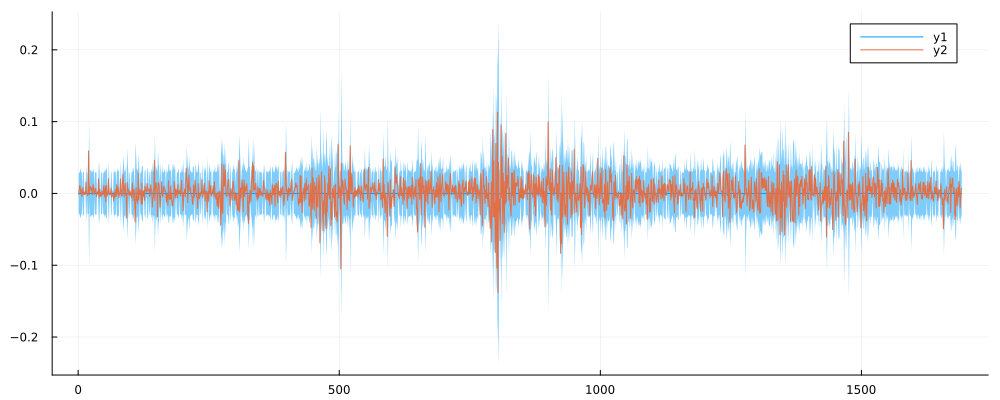

In [65]:
hardprobs = []
for i in 1:length(rets)
    amax = argmax(f_probs[:,i])
    push!(hardprobs,Flux.unstack(dists,2)[i][amax])
end
plot(zeros(length(rets)), ribbon = 2 .* std.(hardprobs).*std(rets), size = (1000,400))
plot!(rets)

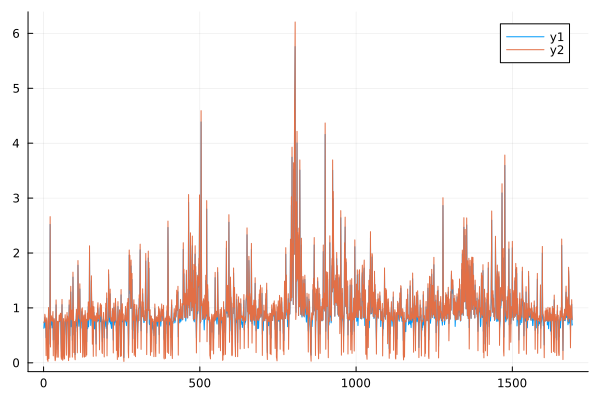

In [66]:
plot(std.(mixprobs))
plot!(std.(hardprobs))

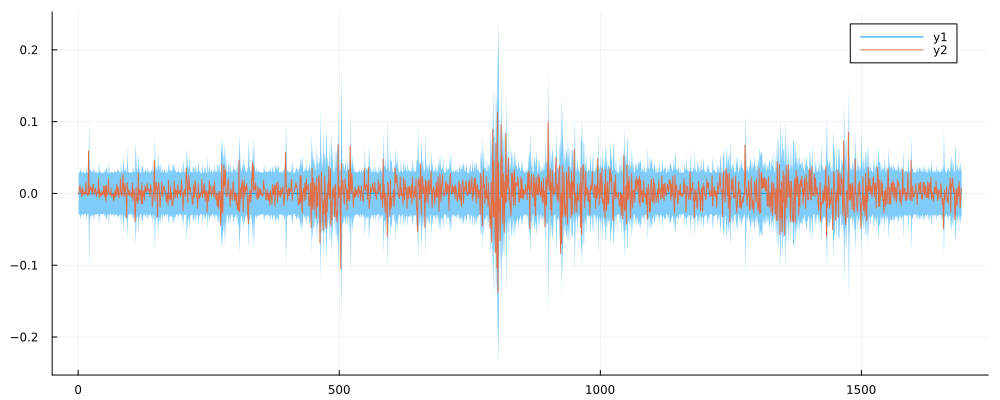

In [67]:
first_probs = []
for i in 1:length(rets)
    push!(first_probs,Flux.unstack(dists,2)[i][1])
end
plot(zeros(length(rets)), ribbon = 2 .* std.(first_probs).*std(rets), size = (1000,400))
plot!(rets)

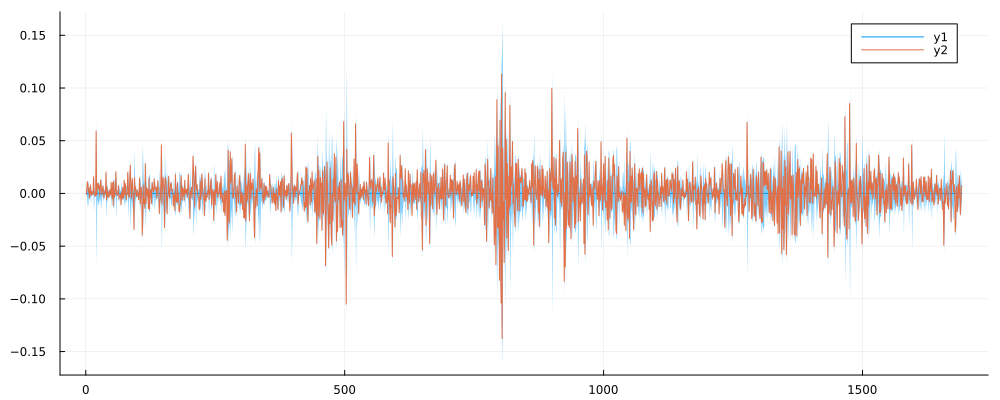

In [68]:
second_probs = []
for i in 1:length(rets)
    push!(second_probs,Flux.unstack(dists,2)[i][2])
end
plot(zeros(length(rets)), ribbon = 2 .* std.(second_probs).*std(rets), size = (1000,400))
plot!(rets)

In [84]:
sqrt.(mean((var.(mixprobs) .* var(rets) .- (rets.-mean(rets)).^2).^2))

0.0009927623658081625

In [85]:
sqrt.(mean((var.(hardprobs) .* var(rets) .- (rets.-mean(rets)).^2).^2))

0.0010443345759667518

In [79]:
sqrt.(mean((var.(first_probs) .* var(rets) .- rets.^2).^2))

0.0010450561202541703

In [86]:
sqrt.(mean((var.(second_probs) .* var(rets) .- (rets.-mean(rets)).^2).^2))

0.0009935707908311604

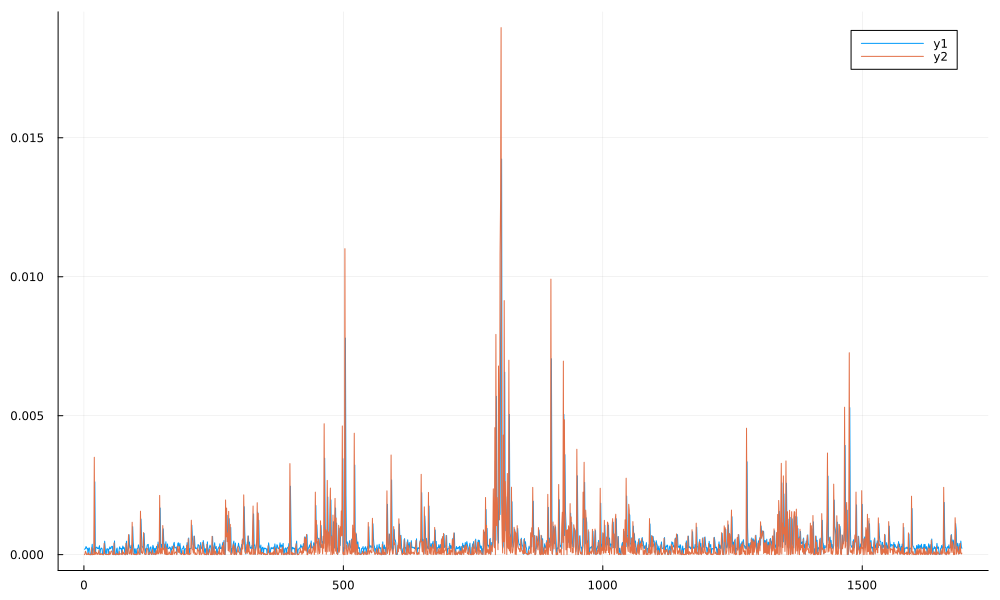

In [74]:
plot(var.(hardprobs).*var(rets),size = (1000,600))
plot!(rets.^2)

In [76]:
softmax(model.transition_probs,dims=2)

2×2 Matrix{Float64}:
 0.969024  0.0309757
 0.155018  0.844982

In [81]:
using Bijectors

In [106]:
MvNormal(ones(1).*2,ones(1).*3)

DiagNormal(
dim: 1
μ: [2.0]
Σ: [9.0;;]
)


In [103]:
pdf(transformed(MvNormal(ones(1)),PlanarLayer(1)),[1.])

0.1369823238797263

In [125]:
struct MSGARCH11_NF #use Gaussian distribution
    initial_state_probs
    transition_probs
    
    alphas
    betas
    omegas
    initial_sigmas
    
    mus
    
    flows
end
Flux.@functor MSGARCH11_NF

function MSGARCH11_NF(n_states::Int) 
    initial_state_probs = randn(n_states) .* 0.1
    transition_probs = randn(n_states, n_states) .* 0.1
    
    alphas = randn(n_states).*0.1
    betas = randn(n_states).*0.1
    omegas = randn(n_states).*0.1
    initial_sigmas = randn(n_states) .* 0.1
    
    mus = zeros(n_states)
    
    flows = [PlanarLayer(1) for _ in 1:n_states]
    
    return MSGARCH11_NF(initial_state_probs, transition_probs, alphas, betas, omegas, initial_sigmas, mus, flows)
end


function get_flowed_distribution(flow, mu, sigma)
    return transformed(MvNormal([mu], [sigma]),flow)
end

function model_filter(m::MSGARCH11_NF, y, y_tm1, sigmas_tm1, state_probs_tm1)     
    transition_probs = softmax(m.transition_probs, dims=2)
    
    alphas = σ.(m.alphas)
    betas = σ.(m.betas) .* (1. .- alphas) #ensure that alpha + beta < 1 --> GARCH stationarity
    omegas = exp.(m.omegas)
    
    mus = m.mus
    
    state_probs_t = transition_probs * state_probs_tm1
    sigmas_t = sqrt.(omegas .+ alphas .* y_tm1.^2 .+ betas .* sigmas_tm1.^2)
    
    y_t = y[1]
    
    flows = m.flows
    dists_t = get_flowed_distribution.(flows,mus,sigmas_t)
    pdfs_t = map(d->pdf(d, [y_t]),dists_t)
    
    filtered_probs_t = state_probs_t .* pdfs_t ./ sum(state_probs_t .* pdfs_t)
    
    if length(y) > 1
        state_probs_tp1, filtered_probs_tp1, dists_tp1, pdfs_tp1 = model_filter(m, y[2:end], y_t, sigmas_t, filtered_probs_t)
        return hcat(state_probs_t, state_probs_tp1), 
               hcat(filtered_probs_t, filtered_probs_tp1),
               hcat(dists_t, dists_tp1),
               hcat(pdfs_t, pdfs_tp1)
    else
        return state_probs_t, filtered_probs_t, dists_t, pdfs_t
    end
end


function filter(m::MSGARCH11_NF, y)
    n_states = length(m.initial_state_probs)
    
    y_t = 0.0
    sigmas_t = exp.(m.initial_sigmas)
    state_probs_t = softmax(m.initial_state_probs)
    
    return model_filter(m, y, y_t, sigmas_t, state_probs_t)
end

filter (generic function with 2 methods)

In [162]:
using Random
Random.seed!(123)

TaskLocalRNG()

In [163]:
model_nf = MSGARCH11_NF(3)
params_nf = Flux.params(model_nf)
opt = ADAM(0.01)

Adam(0.01, (0.9, 0.999), 1.0e-8, IdDict{Any, Any}())

In [164]:
function loglikelihood(m::MSGARCH11_NF, y)
     _,f_probs,_,pdfs = filter(m, y)
    return mean(log.(sum(f_probs.*pdfs,dims=1)))
end

loglikelihood (generic function with 2 methods)

In [165]:
Zygote.gradient(()->loglikelihood(model_nf, rets./std(rets)),params_nf)

Grads(...)

In [166]:
for i in 1:300
    grads = Zygote.gradient(()-> -loglikelihood(model_nf, rets),params_nf)
    Flux.Optimise.update!(opt,params_nf,grads)
    
    if i % 30 == 0
        println(loglikelihood(model_nf, rets))
    end
end 

-0.5505788653867892
1.5256954935659728
1.9677199326853616
2.2184407635417847
2.380737351818923
2.48843158951336
2.5550412361830896
2.5931815478642393
2.6142253728253033
2.625983594077026


In [167]:
_,f_probs_nf,dists_nf,pdfs_nf = filter(model_nf, rets./std(rets))

([0.1002644029471584 0.1270259519635551 … 0.41210886056628254 0.4168917053709446; 0.11541764779880576 0.15030105773130195 … 0.5031405915809103 0.5078510393976152; 0.6790927401281642 0.630394463308918 … 0.12874447644044823 0.12143143929399298], [0.08377492607461128 0.4033777182769246 … 0.37627745381270883 0.4237753855657631; 0.15621910563356184 0.595810860505488 … 0.5848819978825204 0.5759238771450812; 0.7600059682918269 0.0008114212175871783 … 0.03884054830477091 0.00030073728915554253], MultivariateTransformed{DiagNormal, PlanarLayer{Vector{Float64}, Vector{Float64}}}[MultivariateTransformed{DiagNormal, PlanarLayer{Vector{Float64}, Vector{Float64}}}(
dist: DiagNormal(
dim: 1
μ: [0.29027139938727675]
Σ: [0.8827581618625372;;]
)

transform: PlanarLayer{Vector{Float64}, Vector{Float64}}([0.43852140397598444], [0.8118921819929825], [0.6582082286996944])
)
 MultivariateTransformed{DiagNormal, PlanarLayer{Vector{Float64}, Vector{Float64}}}(
dist: DiagNormal(
dim: 1
μ: [0.29027139938727675]


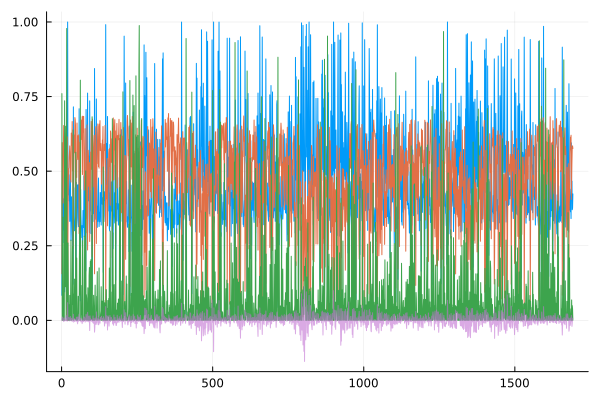

In [168]:
plot(transpose(f_probs_nf),legend = :none)
plot!(rets,alpha=0.6)

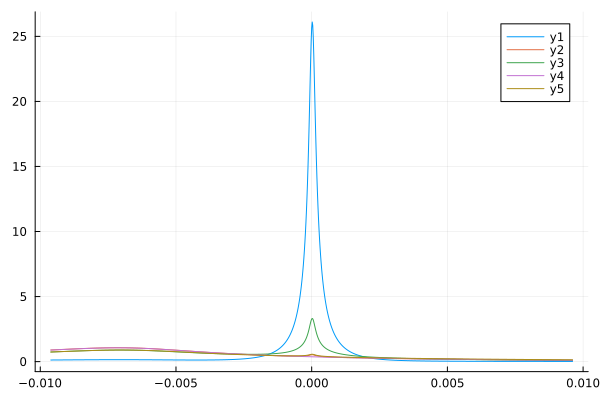

In [173]:
plot(collect(-0.5:0.001:0.5).*std(rets),[pdf(mixprobs[101],[c]) for c in collect(-0.5:0.001:0.5)])
plot!(collect(-0.5:0.001:0.5).*std(rets),[pdf(mixprobs[102],[c]) for c in collect(-0.5:0.001:0.5)])
plot!(collect(-0.5:0.001:0.5).*std(rets),[pdf(mixprobs[103],[c]) for c in collect(-0.5:0.001:0.5)])
plot!(collect(-0.5:0.001:0.5).*std(rets),[pdf(mixprobs[104],[c]) for c in collect(-0.5:0.001:0.5)])
plot!(collect(-0.5:0.001:0.5).*std(rets),[pdf(mixprobs[105],[c]) for c in collect(-0.5:0.001:0.5)])

In [142]:
mixprobs = []
for i in 1:length(rets)
    push!(mixprobs,MixtureModel(Flux.unstack(dists_nf,2)[i], Flux.unstack(f_probs_nf,2)[i]))
end
plot(zeros(length(rets)), ribbon = 2 .* std.(mixprobs).*std(rets), size = (1000,400))
plot!(rets)

LoadError: MethodError: no method matching iterate(::MixtureModel{Multivariate, Continuous, MultivariateTransformed{DiagNormal, PlanarLayer{Vector{Float64}, Vector{Float64}}}, Categorical{Float64, Vector{Float64}}})
[0mClosest candidates are:
[0m  iterate([91m::Union{LinRange, StepRangeLen}[39m) at range.jl:872
[0m  iterate([91m::Union{LinRange, StepRangeLen}[39m, [91m::Integer[39m) at range.jl:872
[0m  iterate([91m::T[39m) where T<:Union{Base.KeySet{<:Any, <:Dict}, Base.ValueIterator{<:Dict}} at dict.jl:712
[0m  ...